In [1]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
%matplotlib inline 
import matplotlib.pyplot as plt
import seaborn as sns

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
h5_fn = "binaural_unit_activations/word_task_half_co_loc_v08_gender_bal_4M_sanity/word_task_half_co_loc_v08_gender_bal_4M_sanity_model_activations_0dB.h5"

h5 = h5py.File(h5_fn, "r") 
print(h5.keys())
for key in h5.keys():
    print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

<KeysViewHDF5 ['attn0_target', 'attn1_gains', 'attn1_target', 'attn2_gains', 'attn2_target', 'attn3_gains', 'attn3_target', 'attn4_gains', 'attn4_target', 'attn5_gains', 'attn5_target', 'attn6_gains', 'attn6_target', 'attncoch_gains', 'attnfc_gains', 'attnfc_target', 'cochleagram_cue', 'cochleagram_fg', 'conv_block_0_ln_cue', 'conv_block_0_ln_target', 'conv_block_0_relu_cue', 'conv_block_0_relu_target', 'conv_block_1_ln_cue', 'conv_block_1_ln_target', 'conv_block_1_relu_cue', 'conv_block_1_relu_target', 'conv_block_2_ln_cue', 'conv_block_2_ln_target', 'conv_block_2_relu_cue', 'conv_block_2_relu_target', 'conv_block_3_ln_cue', 'conv_block_3_ln_target', 'conv_block_3_relu_cue', 'conv_block_3_relu_target', 'conv_block_4_ln_cue', 'conv_block_4_ln_target', 'conv_block_4_relu_cue', 'conv_block_4_relu_target', 'conv_block_5_ln_cue', 'conv_block_5_ln_target', 'conv_block_5_relu_cue', 'conv_block_5_relu_target', 'conv_block_6_ln_cue', 'conv_block_6_ln_target', 'conv_block_6_relu_cue', 'conv_blo

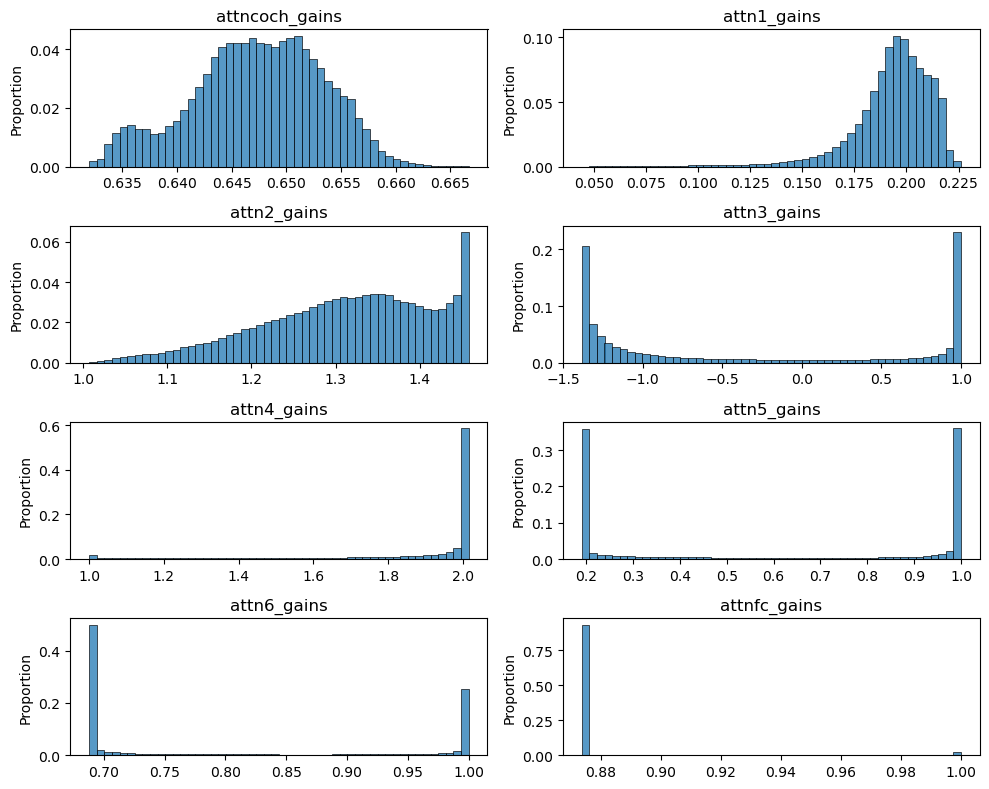

In [4]:
## Plot distribution of gains 
# gain_keys = [key for key in h5.keys() if "gain" in key]
gain_keys = ['attncoch_gains',
'attn1_gains',
 'attn2_gains',
 'attn3_gains',
 'attn4_gains',
 'attn5_gains',
 'attn6_gains',
 'attnfc_gains']

# get number of subplots for gains 
n_gains = len(gain_keys)
n_rows = int(np.ceil(n_gains/2))
n_cols = 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 8))
axs = axs.flatten()
for ix, key in enumerate(gain_keys):
    sns.histplot(data=h5[key][:].flatten(), bins=50, stat='proportion', ax=axs[ix])
    axs[ix].set_title(key)

plt.tight_layout()


### For spatial tuning analysis, average over examples presented at same location, and compare across locations. 



In [6]:

def get_selectivity(ix, acts):
    """ Selectivity index for a given unit 
        defined as act_i / sum(act_i) for all i
    """
    acts_i = acts[ix,:]
    selectivity = acts_i / np.nansum(acts, axis=0)
    return selectivity

def get_acts_from_layer(cat_ix_dict, layer):
    acts_to_test = np.zeros((len(cat_ix_dict), h5[layer].shape[1]), dtype=np.float32)
    for jx, (cat, ixs) in enumerate(cat_ix_dict.items()):
        acts_to_test[jx] = np.mean(h5[layer][ixs], axis=0)
    return acts_to_test

def get_unit_selectivity_from_layer(cat_ix_dict, layer, mask_dead_units=True):
    acts_to_test = get_acts_from_layer(cat_ix_dict, layer)
    selectivity_ranks = np.zeros_like(acts_to_test)
    for ix in range(acts_to_test.shape[0]):
        selectivity_ranks[ix, :] = get_selectivity(ix, acts_to_test)
    if mask_dead_units:
        unit_sums = np.nansum(acts_to_test, axis=0)
        unit_mask = unit_sums > 0 
        filtered = selectivity_ranks[:,unit_mask]
        return filtered, unit_mask
    return selectivity_ranks


/tmp/ipykernel_2369987/3601660461.py:6: RuntimeWarning: invalid value encountered in divide
  selectivity = acts_i / np.nansum(acts, axis=0)


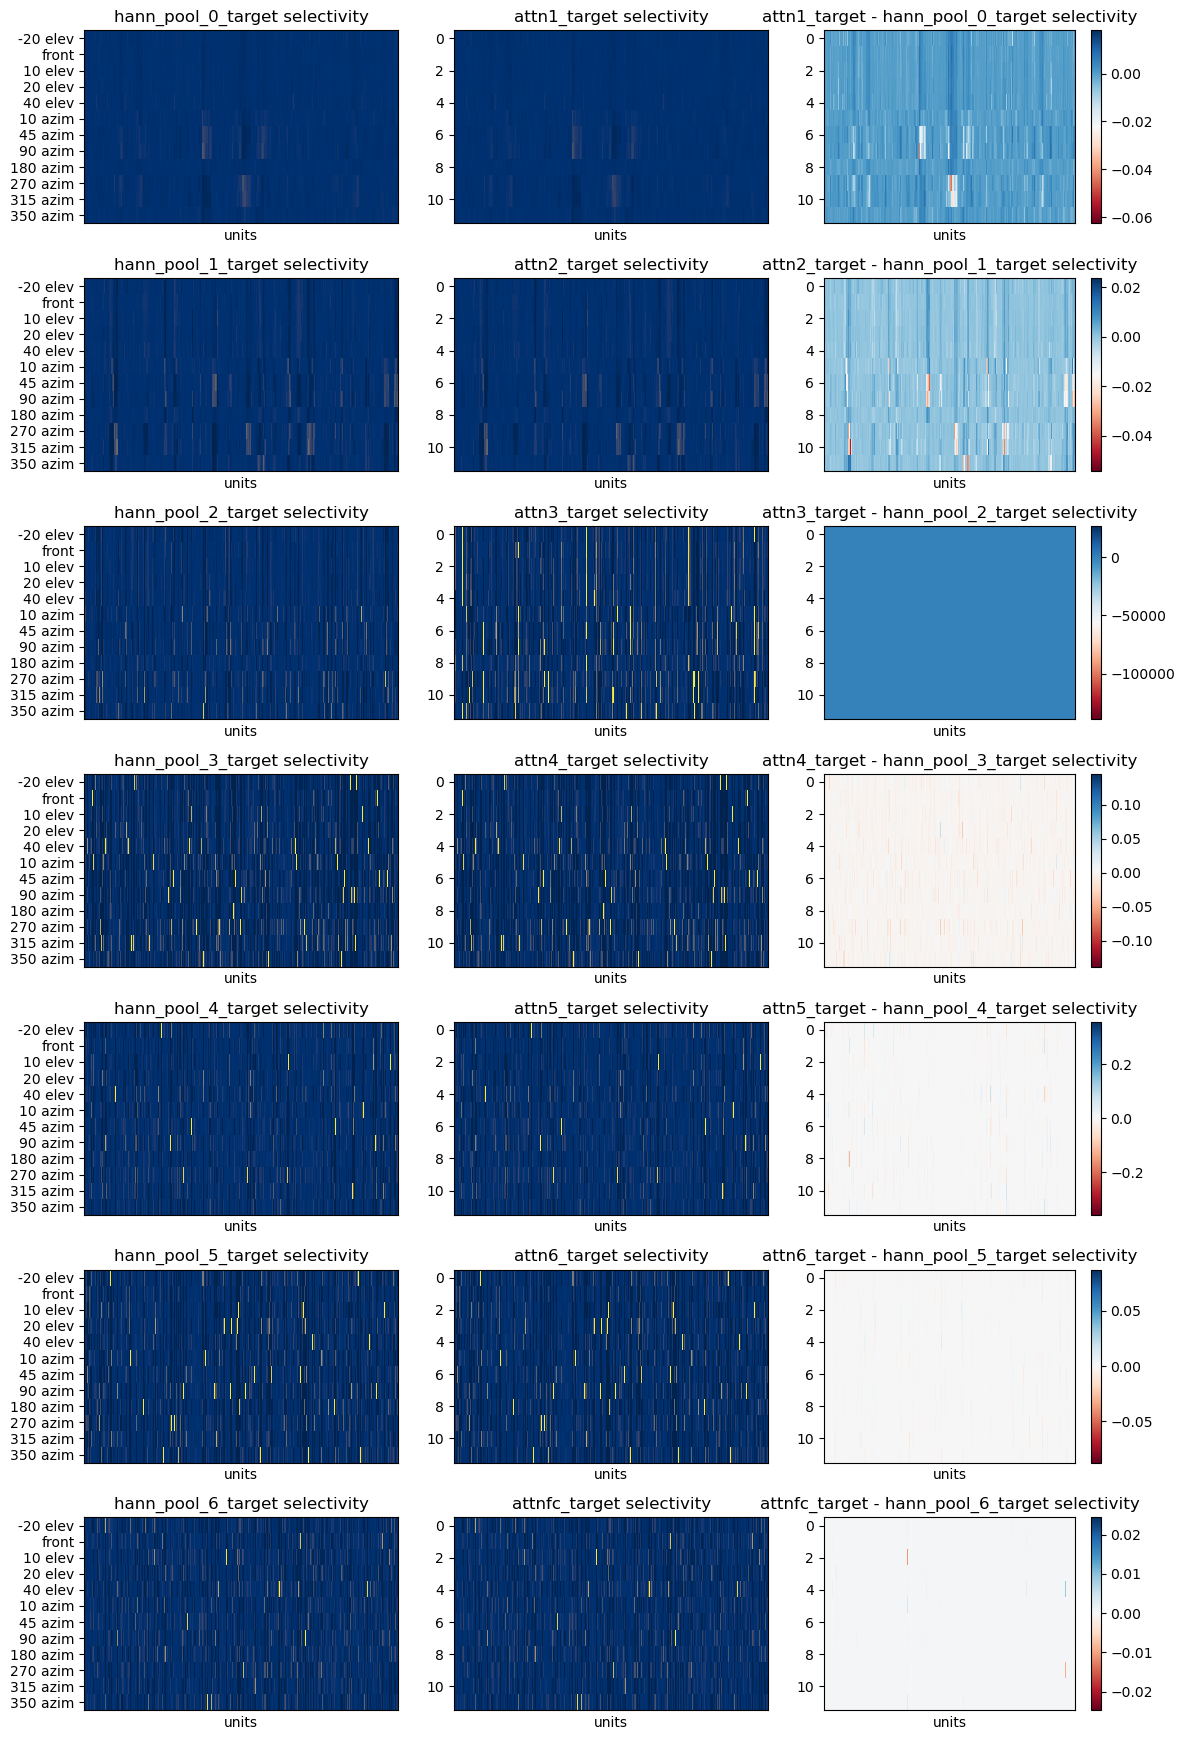

In [60]:
## Get spatial selectivity for each layer
## Get ixs corresponding to locations
#  
unique_locations = np.unique(target_locs, axis=0).astype(int)
# print(unique_locations)
location_ixs = {}
for loc in unique_locations:
    loc_ixs = np.where(np.all(target_locs == loc, axis=1))[0]
    azim, elev = loc
    if elev == 0 and azim == 0:
        location_ixs['front'] = loc_ixs
    elif elev == 0:
        location_ixs[f"{azim} azim"] = loc_ixs
    elif azim == 0:
        location_ixs[f"{elev} elev"] = loc_ixs

layers_to_search = np.arange(0,7) # up to 6
n_layers = len(layers_to_search)
fig, axs = plt.subplots(n_layers,3, figsize=(12, (2.5 * n_layers)))   

for ix, layer_ix in enumerate(layers_to_search):
    layer = f'hann_pool_{layer_ix}_target'
    if ix < 6:
        attn_layer = f'attn{layer_ix+1}_target'
    else:
        attn_layer = 'attnfc_target'

    selectivity_no_attn, unit_mask = get_unit_selectivity_from_layer(location_ixs, layer)
    selectivity_w_attn = get_unit_selectivity_from_layer(location_ixs, attn_layer, mask_dead_units=False)
    selectivity_w_attn = selectivity_w_attn[:,unit_mask]
    selectivity_diff = selectivity_w_attn - selectivity_no_attn

    axs[ix, 0].imshow(selectivity_no_attn, aspect='auto', cmap='cividis', vmin=0, vmax=1, interpolation='None', origin='upper')
    axs[ix, 0].set_yticks(np.arange(selectivity_w_attn.shape[0]), list(location_ixs.keys()));
    axs[ix, 1].imshow(selectivity_w_attn, aspect='auto', cmap='cividis', vmin=0, vmax=1, interpolation='None', origin='upper')
    ax2 = axs[ix, 2].imshow(selectivity_diff, aspect='auto', cmap='RdBu', vmin=selectivity_diff.min(), vmax=selectivity_diff.max(), interpolation='None', origin='upper')
    axs[ix,0].set_title(f"{layer} selectivity")
    axs[ix,1].set_title(f"{attn_layer} selectivity")
    axs[ix,2].set_title(f"{attn_layer} - {layer} selectivity")
    # divider = make_axes_locatable(ax2)
    # cax = divider.append_axes('right', size='5%', pad=0.05)
    plt.colorbar(ax2, ax=axs[ix, 2])
    # remove xticks 
for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_xlabel('units')
plt.tight_layout()

### Get pitch selectivity 

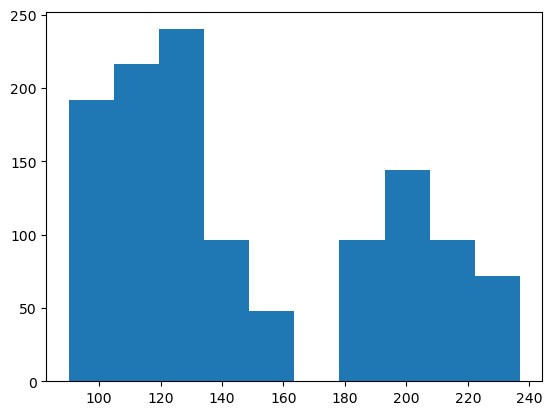

In [17]:
## Need to bin f0 into categories. can cut 
outs = plt.hist(target_f0s, bins=10)
counts, bins = outs[0], outs[1]

10 11


/tmp/ipykernel_2369987/3601660461.py:6: RuntimeWarning: invalid value encountered in divide
  selectivity = acts_i / np.nansum(acts, axis=0)


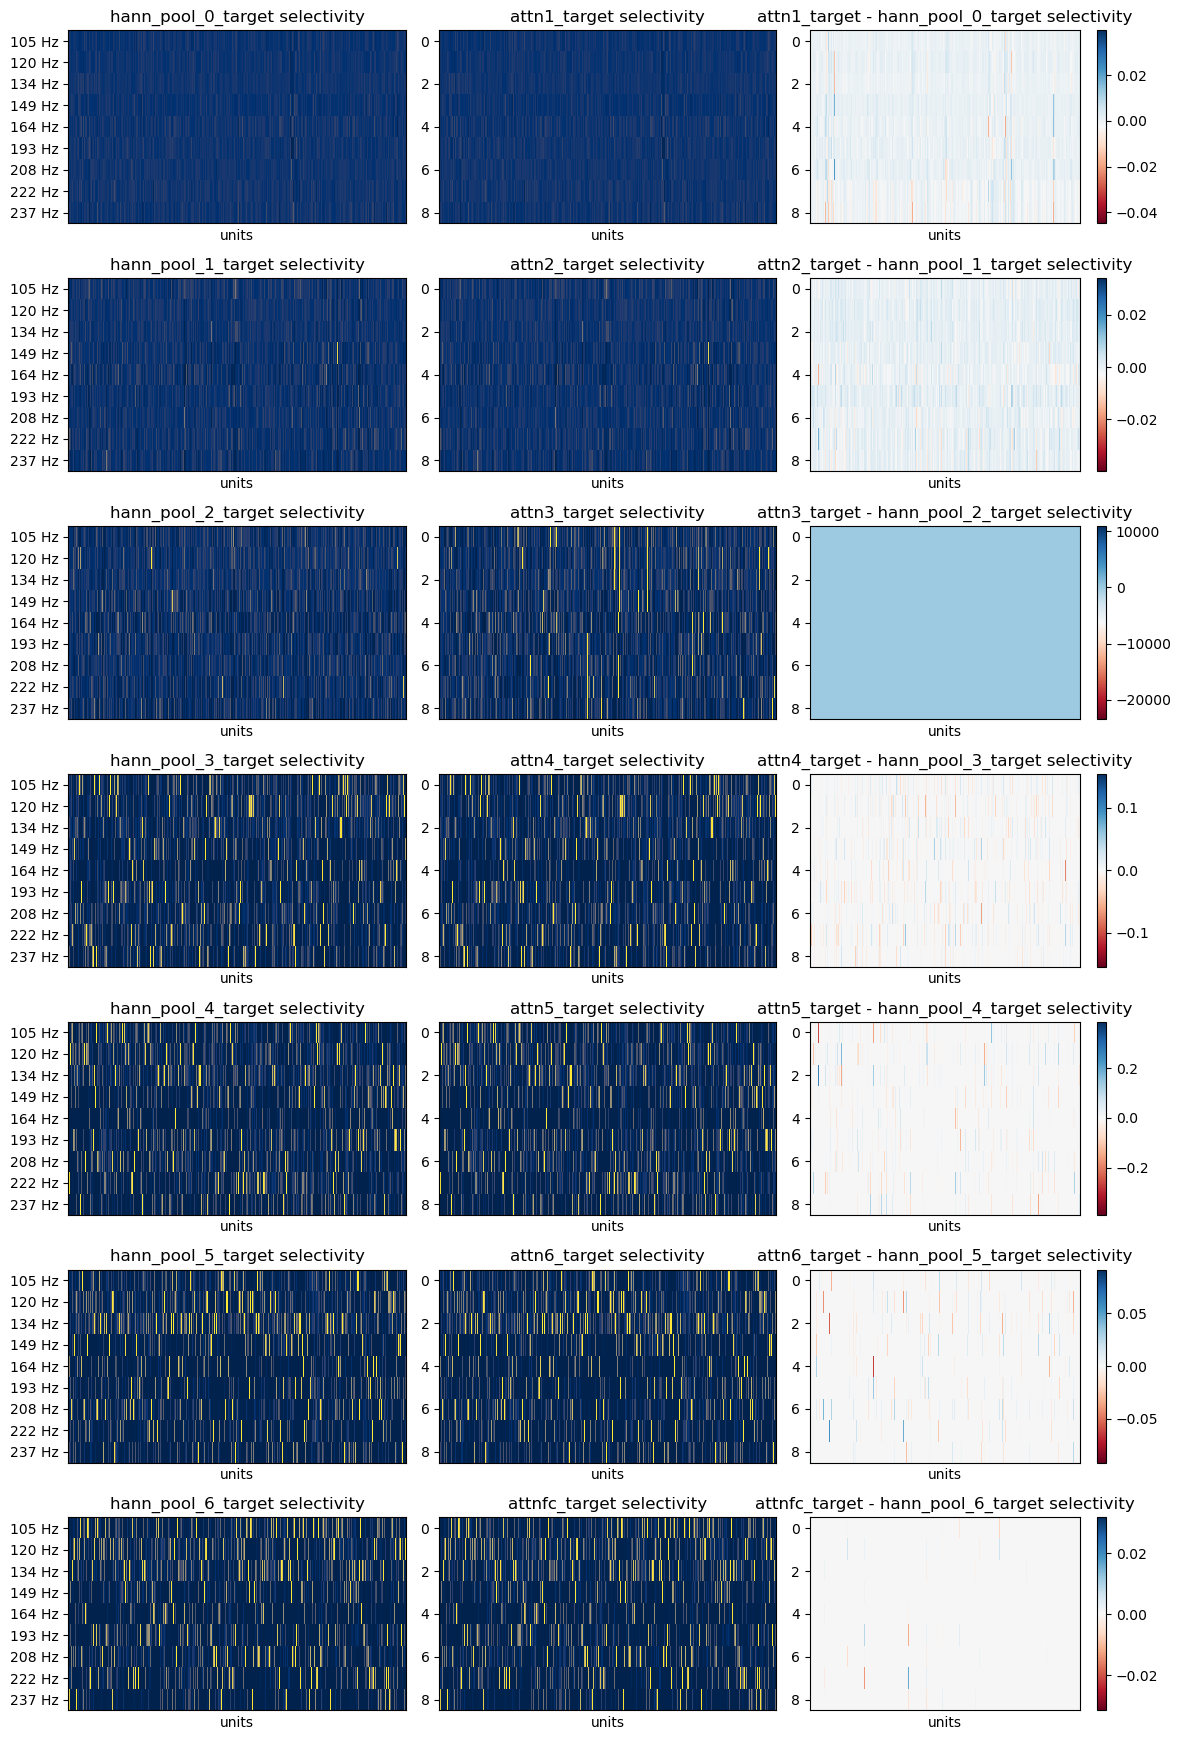

In [54]:
print(len(counts), len(bins))
f0_assignments = np.digitize(target_f0s, bins, right=True)
bins = bins.round(0)
f0_bins = bins[f0_assignments]
f0_bins = f0_bins.astype(int)

# group like with locations 
f0_ixs = {}
for f0 in np.unique(f0_bins):
    f0_ixs[f"{f0} Hz"] = np.where(f0_bins == f0)[0]

layers_to_search = np.arange(0,7) # up to 6
n_layers = len(layers_to_search)
fig, axs = plt.subplots(n_layers,3, figsize=(12, (2.5 * n_layers)))   

for ix, layer_ix in enumerate(layers_to_search):
    layer = f'hann_pool_{layer_ix}_target'
    if ix < 6:
        attn_layer = f'attn{layer_ix+1}_target'
    else:
        attn_layer = 'attnfc_target'
    
    selectivity_no_attn, unit_mask = get_unit_selectivity_from_layer(f0_ixs, layer)
    selectivity_w_attn = get_unit_selectivity_from_layer(f0_ixs, attn_layer, mask_dead_units=False)
    selectivity_w_attn = selectivity_w_attn[:,unit_mask]
    selectivity_diff = selectivity_w_attn - selectivity_no_attn

    axs[ix, 0].imshow(selectivity_no_attn, aspect='auto', cmap='cividis', vmin=0, vmax=selectivity_no_attn.max(), interpolation='None', origin='upper')
    axs[ix, 0].set_yticks(np.arange(selectivity_w_attn.shape[0]), list(f0_ixs.keys()));
    axs[ix, 1].imshow(selectivity_w_attn, aspect='auto', cmap='cividis', vmin=0, vmax=selectivity_w_attn.max(), interpolation='None', origin='upper')
    ax2 = axs[ix, 2].imshow(selectivity_diff, aspect='auto', cmap='RdBu', vmin=selectivity_diff.min(), vmax=selectivity_diff.max(), interpolation='None', origin='upper')
    axs[ix,0].set_title(f"{layer} selectivity")
    axs[ix,1].set_title(f"{attn_layer} selectivity")
    axs[ix,2].set_title(f"{attn_layer} - {layer} selectivity")
    # divider = make_axes_locatable(ax2)
    # cax = divider.append_axes('right', size='5%', pad=0.05)
    plt.colorbar(ax2, ax=axs[ix, 2])
    # remove xticks 
for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_xlabel('units')
plt.tight_layout()